In [115]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification,make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor,plot_tree

In [119]:
X,y = make_regression(n_samples = 100, n_features = 2)

In [121]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size =0.2,random_state =42)

In [141]:
class my_GradDescent:
    
    def __init__(self,n_estimators = 100, learning_rate = 0.1, max_depth = 15):
        
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        
        self.models = []
        self.initial_prediction = None
        self.loss_history = []

    

    def fit(self,X,y):
        
        self.initial_prediction =  np.mean(y)
        predictions = np.full(
            shape = len(y),
            fill_value = self.initial_prediction
                             )
        
        for i in range(self.n_estimators):
            
            residuals = y - predictions
            
            dt = DecisionTreeRegressor(max_depth = self.max_depth)
            
            dt.fit(X,residuals)


            tree_pred  = dt.predict(X) 

            predictions += self.learning_rate * tree_pred

            self.models.append(dt)

            mse =np.mean( (y - predictions) ** 2 )

            self.loss_history.append(mse)
            
        return self


    def predict(self,X):

        predictions = np.full(shape = X.shape[0],
                             fill_value = self.initial_prediction
                             )

        for dt in self.models:

            predictions += (self.learning_rate *  dt.predict(X))
            plot_tree(dt)
        return pd.DataFrame(predictions)



                            



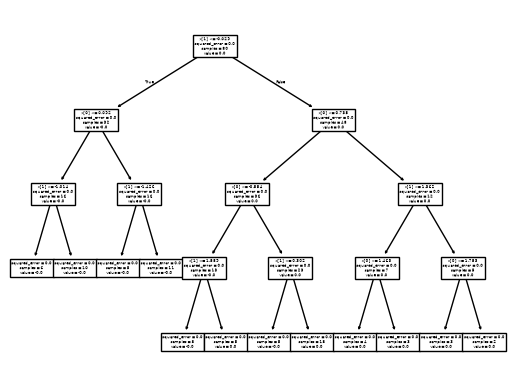

In [147]:
gb = my_GradDescent(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=15
)

gb.fit(x_train, y_train)
y_pred = gb.predict(x_test)

In [148]:
from sklearn.metrics import r2_score, mean_squared_error
print('MSE:',mean_squared_error(y_test,y_pred))
print('R2 Score:',r2_score(y_test,y_pred))

MSE: 1284.8697414181463
R2 Score: 0.8672167915711197
